In [1]:
# load relevant libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# load the weekly interval df
weekly_sentiments = pd.read_csv("../01_data/clean_labelled_data/weekly_sentiment_scores.csv")

In [2]:
# reduce the df to the relevant parties
weekly_sentiments_reduced = weekly_sentiments[weekly_sentiments["faction"].isin(["SPD", "Grünen", "Die LINKE"])]

# remove only period of the caretaker government
weekly_sentiments_reduced = weekly_sentiments_reduced[(weekly_sentiments_reduced["week_start"] <= "2025-02-23") | (weekly_sentiments_reduced["week_start"] >= "2025-03-25")]

In [3]:
weekly_sentiments_reduced["period"] = pd.cut(
    weekly_sentiments_reduced["week_start"],
    bins=[
        pd.Timestamp.min,
        pd.to_datetime("2024-12-27"),
        pd.to_datetime("2025-02-23"),
        pd.Timestamp.max
    ],
    labels=["pre-campaign", "campaign", "post-election"],
    right=True
)

In [4]:
# run the analysis
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    model = smf.mixedlm(
        "mean_sentiment_score ~ period * faction + week_index + gender + mandate",
        data=weekly_sentiments_reduced,
        groups=weekly_sentiments_reduced["full_name"],
        re_formula="~ week_index"
    )
    result = model.fit(method="lbfgs")

print(result.summary())

                       Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       mean_sentiment_score
No. Observations:       2489          Method:                   REML                
No. Groups:             141           Scale:                    5.0182              
Min. group size:        1             Log-Likelihood:           -5652.3541          
Max. group size:        57            Converged:                Yes                 
Mean group size:        17.7                                                        
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                 -1.399    0.494 -2.829 0.005 -2.368 -0.430
period[T.campaign]                         0.452    0.407  1.111 0.266 -0.345  1.249
peri

In [8]:
# encode to category data types
weekly_sentiments_reduced["faction"] = weekly_sentiments_reduced["faction"].astype("category")
weekly_sentiments_reduced["period"] = weekly_sentiments_reduced["period"].astype("category")
weekly_sentiments_reduced["gender"] = weekly_sentiments_reduced["gender"].astype("category")
weekly_sentiments_reduced["mandate"] = weekly_sentiments_reduced["mandate"].astype("category")

# extract all categories from factions and periods
factions = weekly_sentiments_reduced["faction"].cat.categories
periods = weekly_sentiments_reduced["period"].cat.categories

# create a grid with all combinations of faction and period
grid = pd.DataFrame(
    [(f, p) for f in factions for p in periods],
    columns=["faction", "period"]
)

# set covariates to typical/reference values from the original data
grid["week_index"] = weekly_sentiments_reduced["week_index"].mean()
grid["gender"] = weekly_sentiments_reduced["gender"].mode()[0]
grid["mandate"] = weekly_sentiments_reduced["mandate"].mode()[0]

# ensure that the categories match in the grid with the actual categories
for col in ["faction","period","gender","mandate"]:
    grid[col] = pd.Categorical(grid[col], categories=weekly_sentiments_reduced[col].cat.categories)

# create empty lists to store bootstrap predictions and coefficients
boot_preds = []
boot_coefs = []

# get all unique MP names (for resampling)
groups = weekly_sentiments_reduced["full_name"].unique()

# create variables for the number of bootstrap iterations and to store number of non-converged models
n_boot = 1000
num_non_convergence = 0

# loop over all bootstrap iterations
for i in range(n_boot):

    # resample clusters (MPs) with replacement
    sampled_groups = np.random.choice(groups, size=len(groups), replace=True)
    boot_df = pd.concat([weekly_sentiments_reduced[weekly_sentiments_reduced["full_name"]==g] for g in sampled_groups])
    
    # fit model on the bootstrap df
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.simplefilter("ignore", UserWarning)
        boot_model = smf.mixedlm(
            "mean_sentiment_score ~ period * faction + week_index + gender + mandate",
            data=boot_df,
            groups=boot_df["full_name"],
            re_formula="~ week_index"
        ).fit(method="lbfgs")
    
    # check if the model converged, only store predictions if it did
    if not boot_model.converged:
        num_non_convergence += 1
    else:
        pred = boot_model.predict(grid)
        boot_preds.append(pred.values)
        # explicitly extract relevant coefficients and append to list
        campaign_linke = boot_model.params.iloc[1]
        int_campaign_grüne = boot_model.params.iloc[7]
        int_campaign_spd = boot_model.params.iloc[9]
        boot_coefs.append((campaign_linke, int_campaign_grüne, int_campaign_spd))

# print how many models did not converge
prop_non_convergence = (num_non_convergence/n_boot)*100
print(f"{prop_non_convergence:.2f}% of all bootstrap models failed to converge.")
        
# convert to numpy array for percentile calculation
boot_preds = np.array(boot_preds)

# calculate mean of bootstrap predictions as well as confidence intervals
grid["mean"] = boot_preds.mean(axis=0)
grid["ci_lower"] = np.percentile(boot_preds, 2.5, axis=0)
grid["ci_upper"] = np.percentile(boot_preds, 97.5, axis=0)

7.30% of all bootstrap models failed to converge.


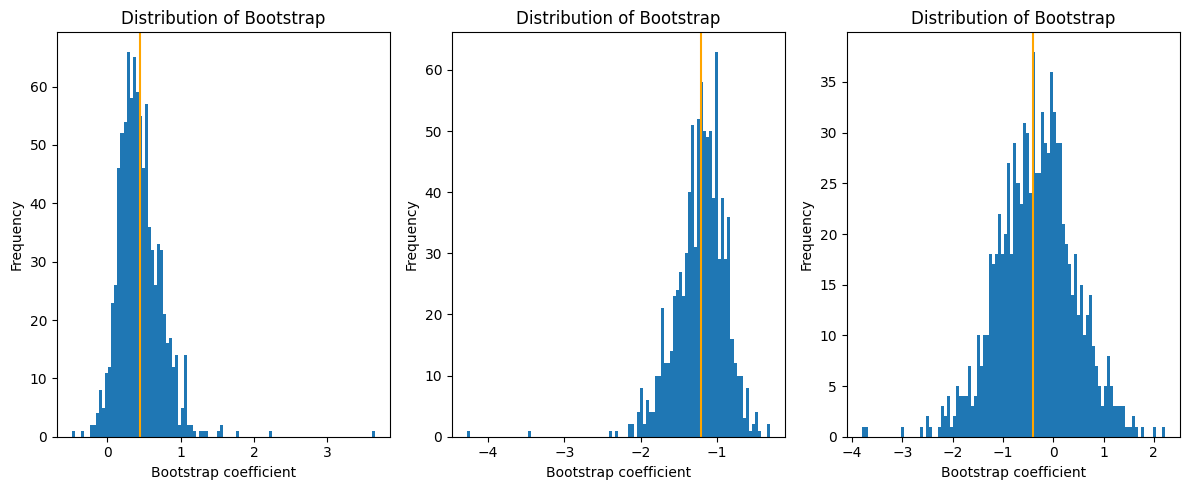

In [11]:
list_campaign_linke = [entry[0] for entry in boot_coefs]
list_int_campaign_grüne = [entry[1] for entry in boot_coefs]
list_int_campaign_spd = [entry[2] for entry in boot_coefs]

# create the figure and axes
fig, ax = plt.subplots(1, 3, figsize=(12,5))

# create histograms
ax[0].hist(list_campaign_linke, bins=100)
ax[1].hist(list_int_campaign_grüne, bins=100)
ax[2].hist(list_int_campaign_spd, bins=100)

# set vertical lines at the originally estimated coefficients
ax[0].axvline(result.params.iloc[1], color="orange")
ax[1].axvline(result.params.iloc[7], color="orange")
ax[2].axvline(result.params.iloc[9], color="orange")

# define axes labels and title
ax[0].set_xlabel("Bootstrap coefficient")
ax[1].set_xlabel("Bootstrap coefficient")
ax[2].set_xlabel("Bootstrap coefficient")
ax[0].set_ylabel("Frequency")
ax[1].set_ylabel("Frequency")
ax[2].set_ylabel("Frequency")
ax[0].set_title("Distribution of Bootstrap")
ax[1].set_title("Distribution of Bootstrap")
ax[2].set_title("Distribution of Bootstrap")

# show the plot
plt.tight_layout()
plt.show()

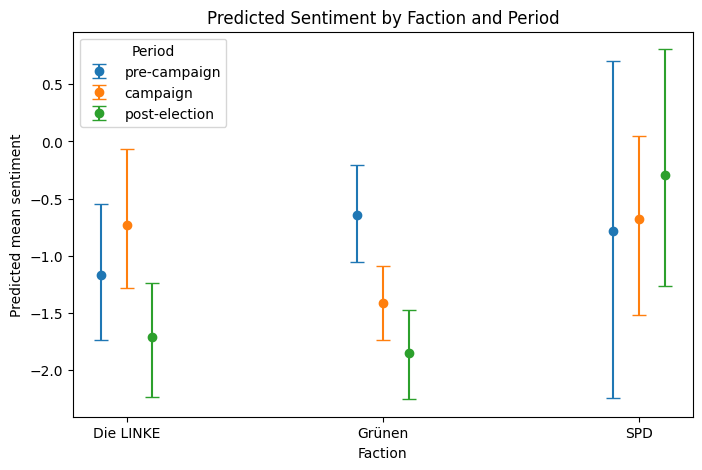

In [12]:
plt.figure(figsize=(8,5))

# X positions for parties
x = np.arange(len(factions))
width = 0.1  # width for dodging the period points

periods_list = grid["period"].cat.categories

for i, period in enumerate(periods_list):
    subset = grid[grid["period"] == period]
    # shift x positions to dodge points
    plt.errorbar(
        x + (i - (len(periods_list)-1)/2)*width,
        subset["mean"],
        yerr=[subset["mean"] - subset["ci_lower"], subset["ci_upper"] - subset["mean"]],
        fmt='o',
        capsize=5,
        label=period
    )

plt.xticks(x, factions)
plt.ylabel("Predicted mean sentiment")
plt.xlabel("Faction")
plt.title("Predicted Sentiment by Faction and Period")
plt.legend(title="Period")
plt.show()